# rBergomi Deep Calibration

Phase 1 ML capstone. Train a neural network to approximate the rBergomi forward map
$(H, \eta, \rho, v_0) \mapsto$ IV surface, using the certified Monte Carlo pricer as
ground truth. Calibration then becomes gradient descent on the network's *inputs* against
a target surface, milliseconds instead of slow-MC-per-evaluation.

Discipline: the pricer is ground truth, the network imitates the pricer, and we validate
the network against the pricer, never against the market. Market calibration is a separate,
later step. The network is a fast approximator on a certified baseline, not a black-box
predictor of a low-signal quantity.

Pipeline (all in `calibration/deep_cal/`): `surface.py` (params to surface), `dataset.py`
(generator), `network.py` (the MLP), `train.py` (training + node weighting + checkpoint),
`calibrate.py` (frozen-network input optimisation).

## Setup

Run from the repo root so relative `artifacts/` paths resolve. The `os.chdir("..")` hops up
from `notebooks/`; run it once (re-running keeps climbing, so restart the kernel if you do).

In [1]:
import os
os.chdir("..")            # notebooks/ -> repo root
print("cwd:", os.getcwd())

import numpy as np
import torch
import matplotlib.pyplot as plt

from calibration.deep_cal.surface import (
    rbergomi_iv_surface, MATURITIES, LOG_MONEYNESS, SURFACE_SHAPE,
)
from calibration.deep_cal.train import train, load_dataset, Scaler
from calibration.deep_cal.network import SurfaceNet
from calibration.deep_cal.calibrate import calibrate

cwd: D:\GitHub\quant-project


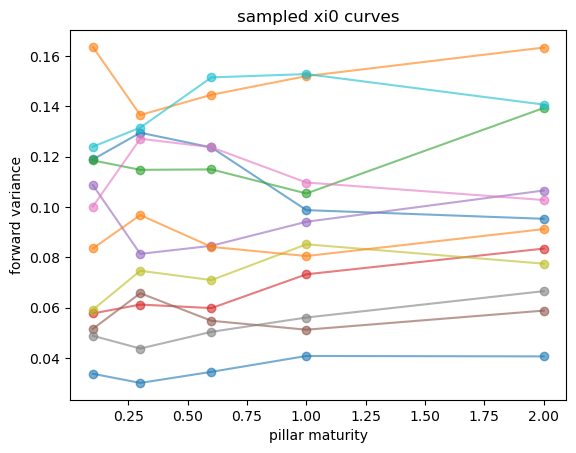

In [2]:
from calibration.deep_cal.dataset import sample_params
from calibration.deep_cal.surface import XI0_PILLARS

P = sample_params(12, np.random.default_rng(0))[:, 3:]   # 12 curves, pillar columns only
for row in P:
    plt.plot(XI0_PILLARS, row, marker="o", alpha=0.6)
plt.xlabel("pillar maturity")
plt.ylabel("forward variance")
plt.title("sampled xi0 curves")
plt.show()

In [3]:
import numpy as np
d = np.load("artifacts/rbergomi_termstructure_dataset.npz", allow_pickle=True)
print("surfaces:", d["surfaces"].shape)      # expect (4000, 8, 11)
print("params:", d["params"].shape)          # expect (4000, 8)
print("reject rate:", float(d["reject_rate"]))
print("param names:", d["param_names"])
print("any NaN in surfaces:", np.isnan(d["surfaces"]).any())

surfaces: (4000, 8, 11)
params: (4000, 8)
reject rate: 0.0
param names: ['H' 'eta' 'rho' 'xi0_0' 'xi0_1' 'xi0_2' 'xi0_3' 'xi0_4']
any NaN in surfaces: False


## 1. Per-node MC noise (measured, not guessed)

Hold the parameters fixed and simulate the surface with 30 different seeds. The std across
seeds at each node is the pure Monte Carlo noise, with the signal held constant. This drives
two decisions: which nodes to drop (informationless), and how to weight the rest
(inverse-noise). Expect the short-maturity deep wings to be far noisier than the interior,
and at least one node to floor to ~0 (a dead node the inversion returns as a constant).

In [4]:
from calibration.deep_cal.surface import rbergomi_iv_surface, XI0_PILLARS
# a representative interior curve: mid-level, gentle shape
pillars = np.full(len(XI0_PILLARS), 0.04)      # flat-ish mid curve for the noise probe
stack = np.array([rbergomi_iv_surface(0.11, 1.8, -0.7, pillars, n_paths=30_000,
                  rng=np.random.default_rng(s)) for s in range(30)])
noise = stack.std(axis=0)
np.save("artifacts/node_noise_ts.npy", noise)
print("worst noise node:", np.unravel_index(np.argmax(noise), noise.shape), noise.max().round(4))

worst noise node: (np.int64(1), np.int64(10)) 0.099


### Visualise the noise field

A heatmap makes the structure obvious: a clean interior and a few hot nodes in the
short-maturity wings. Those hot nodes are what the training weighting and the validity
mask exist to handle.

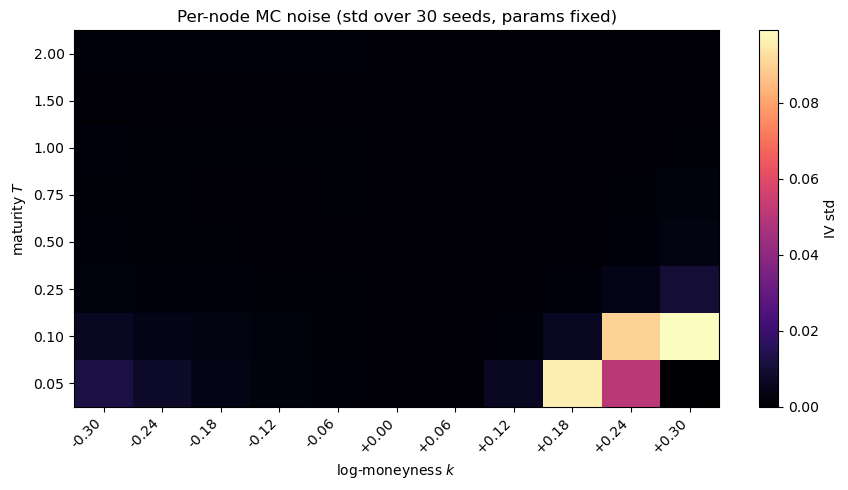

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(noise, aspect="auto", origin="lower", cmap="magma")
ax.set_xticks(range(len(LOG_MONEYNESS)))
ax.set_xticklabels([f"{k:+.2f}" for k in LOG_MONEYNESS], rotation=45, ha="right")
ax.set_yticks(range(len(MATURITIES)))
ax.set_yticklabels([f"{T:.2f}" for T in MATURITIES])
ax.set_xlabel("log-moneyness $k$")
ax.set_ylabel("maturity $T$")
ax.set_title("Per-node MC noise (std over 30 seeds, params fixed)")
fig.colorbar(im, label="IV std")
fig.tight_layout()
plt.show()

## 2. Train the network

`train` splits before fitting scalers (no val leakage), standardises inputs and outputs,
drops nodes noisier than `noise_max`, and weights the survivors by inverse noise **in
standardised target units** (so the loss is well scaled). Early stopping on val loss.

The scalers, the validity mask, and the node weights are all saved in the checkpoint,
because calibration must apply the identical transform and mask at inference.

Sanity check on the very first line: epoch-0 train loss should be order 1, not hundreds.
A loss in the hundreds means the weights are in the wrong units (raw-IV noise applied to
standardised residuals).

In [6]:
noise = np.load("artifacts/node_noise_ts.npy")
res = train(dataset_name="rbergomi_termstructure_dataset.npz",
            checkpoint_name="surfacenet_ts.pt",
            noise=noise, epochs=2000, seed=0)
print("RMSE:", round(res["rmse_vol"],5), " max node err:", round(res["max_err"],5))

kept 83/88 nodes
weight min/mean/max: 0.19 / 1.00 / 1.77
epoch    0  train 8.499e+02  val 1.591e+02
epoch   50  train 1.813e+01  val 3.203e+00
epoch  100  train 1.557e+01  val 2.742e+00
epoch  150  train 1.466e+01  val 2.601e+00
epoch  200  train 1.391e+01  val 2.481e+00
epoch  250  train 1.341e+01  val 2.405e+00
epoch  300  train 1.317e+01  val 2.381e+00
epoch  350  train 1.289e+01  val 2.344e+00
epoch  400  train 1.251e+01  val 2.291e+00
epoch  450  train 1.209e+01  val 2.224e+00
epoch  500  train 1.185e+01  val 2.199e+00
epoch  550  train 1.164e+01  val 2.175e+00
epoch  600  train 1.156e+01  val 2.171e+00
epoch  650  train 1.137e+01  val 2.142e+00
epoch  700  train 1.143e+01  val 2.178e+00
epoch  750  train 1.121e+01  val 2.141e+00
early stop at epoch 783, best val 2.137e+00

held-out surface RMSE: 0.00860 vol pts   max node err: 0.36477  (valid nodes)
saved checkpoint to D:\GitHub\quant-project\artifacts\surfacenet_ts.pt
RMSE: 0.0086  max node err: 0.36477


### Training curves

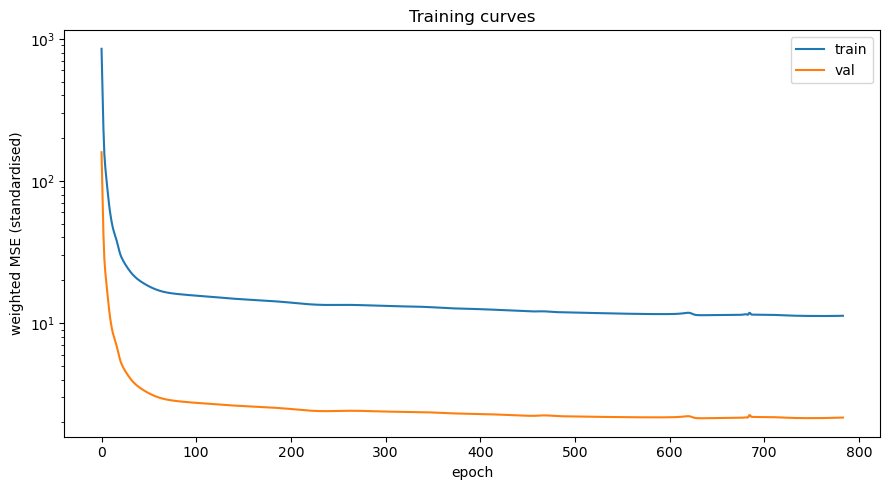

In [7]:
h = res["history"]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h["train"], label="train")
ax.plot(h["val"], label="val")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("weighted MSE (standardised)")
ax.set_title("Training curves")
ax.legend()
fig.tight_layout()
plt.show()

### Worst surviving node

A good average can hide one bad node, so find the worst-fit valid node explicitly. If the
weighting and mask are working, the max error should be a small multiple of the RMSE, not
the ~30x seen when a noisy wing node was dragging the fit.

In [8]:
pred_iv, true_iv, valid = res["pred_iv"], res["true_iv"], res["valid_nodes"]
node_err = np.abs(pred_iv - true_iv).max(axis=0)
node_err[~valid] = 0.0
i = int(np.argmax(node_err))
print("worst valid node", np.unravel_index(i, SURFACE_SHAPE),
      "err", round(float(node_err[i]), 4))
print("dropped nodes:", [tuple(np.unravel_index(j, SURFACE_SHAPE)) for j in np.where(~valid)[0]])

worst valid node (np.int64(0), np.int64(0)) err 0.3648
dropped nodes: [(np.int64(0), np.int64(8)), (np.int64(0), np.int64(9)), (np.int64(0), np.int64(10)), (np.int64(1), np.int64(9)), (np.int64(1), np.int64(10))]


## 3. Synthetic recovery (the certification)

The real test of the whole pipeline: make a surface from KNOWN parameters, calibrate through
the frozen network, and check the parameters come back. Draw the target from the interior of
the trained box (not the edge, so we test accuracy not extrapolation), and price it with more
paths than training so the target is clean.

H is the identifiable parameter (the term-structure slope pins it), so it is the sharpest
check. eta and v0 trade off somewhat, so lean on the overall surface RMSE for those.

In [10]:
H_true, eta_true, rho_true = 0.11, 1.8, -0.7
pillars_true = np.array([0.035, 0.038, 0.040, 0.042, 0.045])   # gently rising curve

target = rbergomi_iv_surface(H_true, eta_true, rho_true, pillars_true,
                             n_paths=100_000, rng=np.random.default_rng(99))

out = calibrate(target, steps=800)

print("scalars recovered:", np.round(out["scalars"], 4),
      " true:", [H_true, eta_true, rho_true])
print("pillars recovered:", np.round(out["pillars"], 4))
print("pillars true:     ", pillars_true)
print("in box:", out["in_box"], " surface RMSE:", round(out["surface_rmse"], 5))

scalars recovered: [ 0.1082  1.8396 -0.6862]  true: [0.11, 1.8, -0.7]
pillars recovered: [0.0352 0.0387 0.0401 0.0404 0.047 ]
pillars true:      [0.035 0.038 0.04  0.042 0.045]
in box: True  surface RMSE: 0.00215


### Recovery readout

If H comes back within a few thousandths and the surface RMSE is small, the pipeline is
certified end to end: params in, surface out, calibrate, params back. This is the deep-cal
analogue of the ground-truth recovery tests used throughout Phase 1.

In [11]:
pred_iv, true_iv, valid = res["pred_iv"], res["true_iv"], res["valid_nodes"]
node_err = np.abs(pred_iv - true_iv).max(axis=0)
node_err[~valid] = 0.0
order = np.argsort(node_err)[::-1][:5]      # top 5 worst
for i in order:
    print(np.unravel_index(i, (8,11)), "err", round(float(node_err[i]),3),
          "noise", round(float(noise.reshape(-1)[i]),4))

(np.int64(0), np.int64(0)) err 0.365 noise 0.012
(np.int64(0), np.int64(1)) err 0.299 noise 0.008
(np.int64(1), np.int64(0)) err 0.196 noise 0.0064
(np.int64(1), np.int64(1)) err 0.177 noise 0.0046
(np.int64(0), np.int64(2)) err 0.166 noise 0.0041


In [12]:
for name, t in zip(["H", "eta", "rho", "v0"], true):
    r = out["params"][name]
    print(f"{name:4s}  true {t:+.4f}   recovered {r:+.4f}   abs err {abs(r-t):.4f}")

H     true +0.1100   recovered +0.1082   abs err 0.0018
eta   true +1.8000   recovered +1.8396   abs err 0.0396
rho   true -0.7000   recovered -0.6862   abs err 0.0138


KeyError: 'v0'

## Next

- Widen $\xi_0$ from flat $v_0$ to a term-structure of forward-variance pillars (extra
  network inputs), regenerate the dataset, retrain, re-certify synthetic recovery.
- Only then load real SPX: parity-implied forward per maturity, quotes to log-moneyness,
  2-D interpolate onto the canonical grid, calibrate, and read the fit against the trusted
  interior nodes (the same dropped wing nodes are unreliable in the market too).